<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignemnts/lecture_2_DCT_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules, including `google.colab.drive` for accessing the required assets for the notebook (`cameraman.png`) from Google Drive

In [1]:
from skimage.io import imread  # pyright: ignore[reportMissingImports]
from google.colab import drive  # pyright: ignore[reportMissingImports]
from scipy.fft import dct, idct
from matplotlib import pyplot as plt
import numpy as np

Mount your Google Drive folders, located at `/content/drive`, on the local runtime filesystem and define the root folder for the project

In [2]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


# 2-D DCT
The goal of this section is to define and use the dictionary representing the 2-D DCT

Let $s$ be a $p\times p$ patch extract from an image. We can see $s$ as a vector of dimension $M=p^2$  
We can move from one representation to the other one through a `reshape` operation


The following code defines two functions: `dct2` and `idct2`  
The `dct2` function computes the coefficient $x\in\mathbb{R}^M$ of a patch $s\in\mathbb{R}^M$, while the `idct2` is the inverse function
$$
x = \text{dct2}(s) = D^Ts, \qquad s = \text{idct2}(x) = Dx
$$

NB: here $D$ is *not* the 1-D DCT matrix

In [3]:
def dct2(s):
    return dct(dct(s.T, norm='ortho').T, norm='ortho')


def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

Useful function for plotting the 2-D DCT dictionary

In [4]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Set the patch size

In [5]:
p = 8  # patch size
M = p ** 2  # number of elements in the patch

Load the image and extract a patch

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

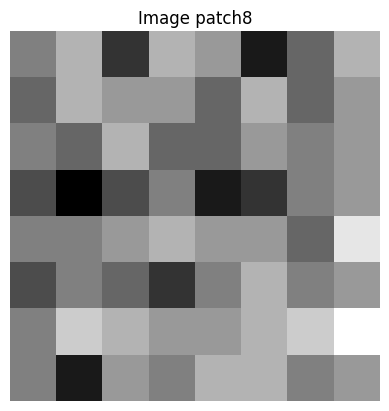

In [6]:
# Bring the image in [0,1] range
img = imread(f'{ROOT_FOLDER}/cameraman.png') / 255

# Extract patch, in position (8,8), from the image
PATCH_IDX = 8
s_block = img[PATCH_IDX:PATCH_IDX + p, PATCH_IDX:PATCH_IDX + p]

# Unroll the patch
s = np.reshape(s_block, M)

# Show the patch
plt.imshow(s_block, cmap='gray')
plt.title('Image patch' + str(PATCH_IDX))
plt.axis('off')

### Compute the 2-D DCT matrix (M x M)

To build the matrix $D$ corresponding to the 2-D DCT, we can use the `idct2` function

In [7]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        # Construct the basis element E
        E = np.zeros((p, p))
        E[i, j] = 1.0
        D[:, cnt] = idct2(E).reshape(-1)  # Infer the dimension for reshaping
        cnt = cnt + 1

Verify that $D$ is orthonormal

In [8]:
is_D_orth = np.all(np.abs(D @ D.T - np.eye(M)) < 1e-10)
print(f'DCT dictionary is orthogonal: {is_D_orth}')

DCT dictionary is orthogonal: True


All the atoms in $D$ can be seen as patch  
Let's plot them!

(np.float64(-0.5), np.float64(77.5), np.float64(77.5), np.float64(-0.5))

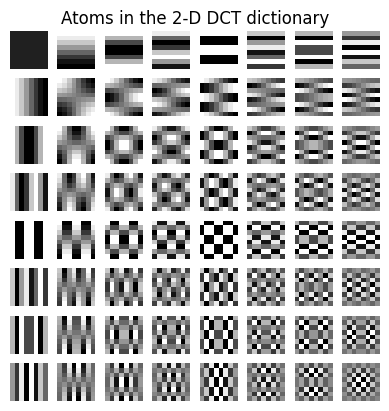

In [9]:
D_img = get_dictionary_img(D)
plt.imshow(D_img, cmap='gray')
plt.title('Atoms in the 2-D DCT dictionary')
plt.axis('off')

Compute the representation w.r.t. the 2-D DCT matrix

In [10]:
x = D.T @ s

### Separable 2-D DCT

Build the 1-D DCT matrix

In [11]:
D1 = np.zeros((p, p))
for i in range(p):
    e = np.zeros(p)
    e[i] = 1.0
    D1[:, i] = idct(e, norm='ortho')

Compute the representation `x_block` w.r.t. the 2-D DCT dictionary exploiting the separability  
In this case do not unroll the patch: the coefficients will be organized in a $p\times p$ matrix

In [12]:
x_block = D1.T @ s_block @ D1

Check if the coefficients computed using the two methods are equal

In [13]:
is_coeff_equal = np.all(np.abs(x_block.reshape(-1) - x) < 1e-10)
print(f'The two vectors of coefficients are the same: {is_coeff_equal}')

The two vectors of coefficients are the same: True


# JPEG Compression

The goal of this section is to implement the compression algorithm at the core of JPEG compression

The idea is to divide the image in $8\times 8$ non overlapping patches and to compress each patch separately. More precisely, given a patch $s$ and its coefficient vector $x$ w.r.t. the DCT basis, we keep only the coefficients having a magnitude larger than a compression threshold $\tau$. In practice, a larger $\tau$ yields a greater compression ratio, where we define the compression ratio as
$$
\text{Comp Ratio} = 1 - \frac{\#\text{Non zero coefficients}}{\#\text{pixel in the image}}
$$

The larger the compression ratio, the smaller the amount of memory we need to store the compressed image

Another figure of merit we use to evaluate the compression is the PSNR
$$
\text{PSNR} = 10\log_{10}\frac{1}{\text{MSE}(Y, \widehat Y)}
$$
where $Y$ is the original, uncompressed image, $\widehat Y$ is the compressed image, and $\text{MSE}$ is the Mean Squared Error


In [14]:
# Set the threshold for the compression
threshold = 0.5

Initialize the compressed image and the number of nonzero coefficients

In [15]:
img_comp = np.zeros_like(img)
nnz_coeff = 0

Process the image patch-wise

In [17]:
for i in range(0, img.shape[0], p):
    for j in range(0, img.shape[1], p):
        # Extract the patch
        s = img[i:i + p, j: j + p].reshape(M)

        # Compute the representation w.r.t. the 2D DCT dictionary
        x = D.T @ s

        # Perform the hard thresholding (do not perform HT on the DC!)
        x_HT = x.copy()
        x_HT[1:][np.abs(x_HT[1:]) < threshold] = 0.0

        # Reconstruct the patch
        s_hat = D @ x_HT

        # Put the compressed patch into the compressed image
        img_comp[i:i+p, j:j+p] = s_hat.reshape(p, p)

        # Update the total number of nonzero coefficient
        nnz_coeff += np.count_nonzero(x_HT)

Compute the PSNR

In [ ]:
psnr = 10 * np.log10(1/np.square(np.subtract(img, img_comp)).mean())

Compute the compression ratio

In [ ]:
comp_ratio = 1 - (nnz_coeff/img.size)

Show the original image and the compressed one

Text(0.5, 1.0, 'Compressed Image,\nPSNR = 23.95, compression_ratio = 0.98')

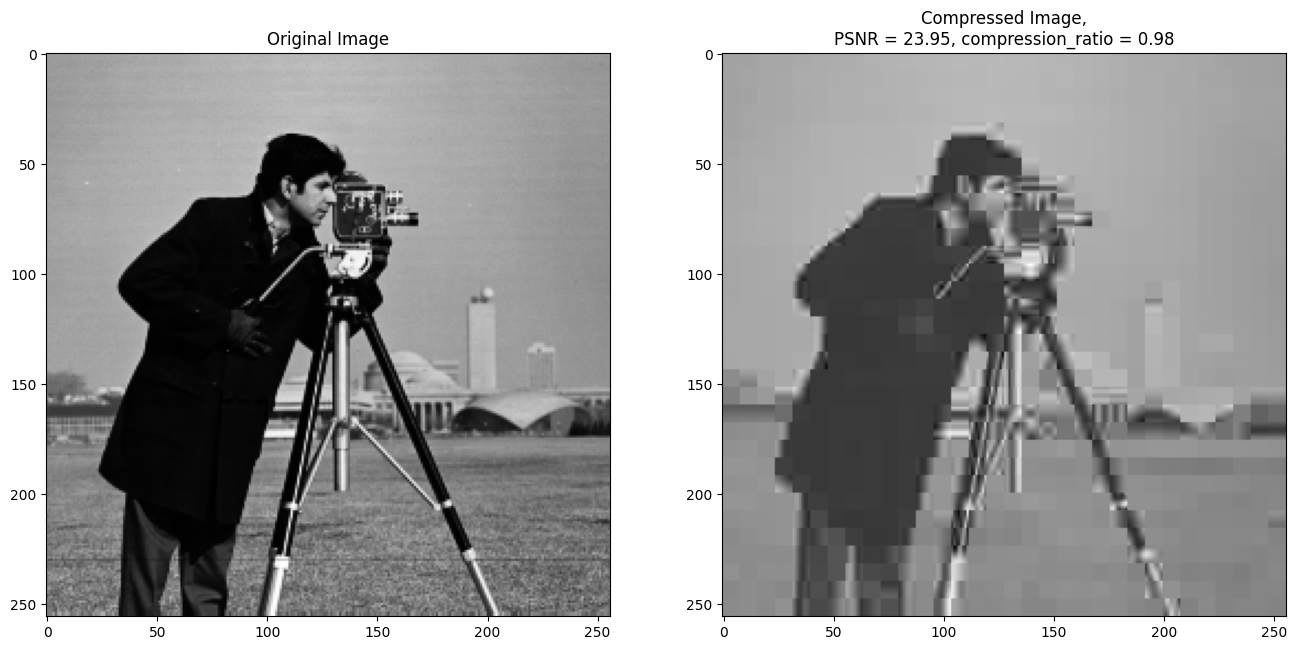

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 12))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(img_comp, cmap='gray')
ax[1].set_title(
    f'Compressed Image,\nPSNR = {psnr:.2f}, compression_ratio = {comp_ratio:.2f}')

By setting a high value for the threshold $\tau$, many coefficients of $x$ (the representation w.r.t. the 2-D DCT dictionary) are set to zero. This allows for a larger compression ratio, at the cost of deteriorating the image quality. This deterioration is reflected by a lower PSNR, indicating a higher Mean Squared Error (MSE) between the original and reconstructed image. Visually, this translates to grainy outputs and blocking artifacts.

On the other hand, when the threshold is relatively small, the fidelity of the compressed image is higher and it remains qualitatively comparable to the original one, resulting in a significantly higher PSNR. However, the effectiveness of the compression is reduced, with a compression ratio closer to 0.